# Connect to the Drive repo

In [ ]:
from pathlib import Path
import os, sys, subprocess

PUBLIC_ID = '1hpzEta1Ub_FlVQszrYXsis0Phirrjh81'
DEST_DIR = Path("/content/drive/My Drive/Finding_ES_LLM")
DRIVE_ROOT = Path("/content/drive")

# Mount

if not DRIVE_ROOT.exists():
    from google.colab import drive
    drive.mount("/content/drive")

# 2) check if the repo folder already exists in their Drive
if not DEST_DIR.exists() or not any(DEST_DIR.iterdir()):
    print("Repo not found in your Drive. Downloading …")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown>=5"])
    DEST_DIR.mkdir(parents=True, exist_ok=True)
    cmd = [
        "gdown", f"https://drive.google.com/drive/folders/{PUBLIC_ID}",
        "--folder", "-O", str(DEST_DIR)
    ]
    subprocess.check_call(cmd)
else:
    print("Repo already present in your Drive -> skipping download")

# 3) put it on sys.path so imports work
sys.path.insert(0, str(DEST_DIR))
print("Repo ready at:", DEST_DIR)

# Setup and imports

In these first two cells we run all the setup for the experiment. If you are met with a numpy dependency error just restart the notebook and it should be gone. Remember to change the file paths and secrets.

In [ ]:
from google.colab import userdata     # Imports secret tokens for logins
from huggingface_hub import login     # Huggingface for fast implementation of transformers

''' Change snippet and secrets below with your data '''

file_path = ('/content/drive/My Drive/Finding_ES_LLM/')
sys.path.append(file_path)
if not os.path.exists('/content/drive/My Drive'):
    from google.colab import drive
    drive.mount('/content/drive')

secrets = {
    'hugging': userdata.get('HF_TOKEN'),
    # 'wandb': userdata.get('wandb_api'),
    # 'nnsight': userdata.get('nnsight'),
    # 'openai': userdata.get('openai_api')
}

HF_TOKEN = secrets['hugging']
login(token=HF_TOKEN)

''' Change snippet and secrets above with your data '''

try:
    import transformer_lens as tlens
    import transformers as trans
    import openai
except:
    #  git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python
    # %pip install wandb -qU
    # %pip install -U bitsandbytes
    # %pip install -U accelerate
    %pip install -U transformers transformer_lens datasets einops jaxtyping
    %pip install openai
    import openai
    import transformer_lens as tlens
    import transformers as trans

"""
try:
    import sae_lens as slens
    from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
    )
    from sae_lens.toolkit.pretrained_saes_directory import get_pretrained_saes_directory
    from sae_vis import SaeVisConfig, SaeVisData, SaeVisLayoutConfig
except:
    # %pip install sae-lens
    #  git+https://github.com/callummcdougall/sae_vis.git@callum/v3
    %pip install openai>=1.56.2 nnsight
    %pip install --upgrade pydantic
    %pip install nnsight
"""

''' Navigate drive '''

import json
import pickle

''' For importing datasets '''

from datasets import load_dataset, Dataset

In [1]:
# import nnsight

# import circuitsvis as cv

''' Tensor manipulation '''

import einops
from einops import einsum
import numpy as np
import torch as t                     # https://pytorch.org/docs/stable/torch.html
import torch.nn as nn                 # https://pytorch.org/docs/stable/nn.html
import torch.nn.functional as F       # https://pytorch.org/docs/stable/nn.functional.html

''' Utils '''

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from rich import print as rprint
from rich.table import Column, Table
from functools import partial         # We need this for fwd_hooks
import copy
from torch.amp import autocast
import gc
import seaborn as sns
import random

''' Should we need strong typing '''

from jaxtyping import Float, Int
from torch import Tensor
from typing import Callable, List, Tuple

''' For visualization of progress (in notebook) and training behavior (in wandb) '''

from tqdm import tqdm
# import wandb
# wandb.login(key=secrets['wandb'])
device = t.device("cuda" if t.cuda.is_available() else "cpu")

''' My things '''

from probes import SupervisedProbe, UnsupervisedProbe, probe_sweep
from visualization import *
from utils import *
from data_sets import *
from intervention import *

ModuleNotFoundError: No module named 'jaxtyping'

# Model and Config

Here we init our model. The experiment is meant to be replicable with most families except gemma. Models from the Gemma family require some tweaking under the hood beacause of a different tokenizer.

We run the model in half precision: most models will be ok with an L4, but for gemma and llama-medium we will need A100's RAM

In [ ]:
MODEL = 'llama'

def get_llama_legacy():

    tokenizer = trans.LlamaTokenizer.from_pretrained('huggyllama/llama-7b')
    hf_model = trans.LlamaForCausalLM.from_pretrained('huggyllama/llama-7b',
                                                      torch_dtype=t.float16,
                                                      device_map='cpu')
    model = tlens.HookedTransformer.from_pretrained(
        "llama-7b",
        hf_model=hf_model,
        device=t.device('cpu'),
        fold_ln=False,
        center_writing_weights=False,
        center_unembed=False,
        tokenizer=tokenizer
    ).half()

    return model
''' Dictionary for all of the models '''

mymodels = {
    'gemma': lambda: tlens.HookedTransformer.from_pretrained("gemma-2-9b", device=t.device('cpu')).half(),
    'gemma_instruct': lambda: tlens.HookedTransformer.from_pretrained("gemma-2-9b-it", device=t.device('cpu')).half(),
    'gpt': lambda: tlens.HookedTransformer.from_pretrained("gpt2-large", device=device),
    'gpt-j': lambda: tlens.HookedTransformer.from_pretrained("EleutherAI/gpt-j-6B", device=t.device('cpu')).half(),
    'llama_legacy': get_llama_legacy,
    'llama': lambda: tlens.HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B", device=t.device('cpu')).half(),
    'llama_instruct': lambda: tlens.HookedTransformer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct", device=t.device('cpu')).half(),
    'llama_medium': lambda: tlens.HookedTransformer.from_pretrained("Llama-2-13b", device=t.device('cpu')).half(),
    'llama_medium_instruct': lambda: tlens.HookedTransformer.from_pretrained("Llama-2-13b-chat", device=t.device('cpu')).half(),
    'pythia': lambda: tlens.HookedTransformer.from_pretrained("pythia-6.9b-deduped", device=t.device('cpu')).half(),
    'pythia_instruct': lambda: tlens.HookedTransformer.from_pretrained("pythia-6.9b", device=t.device('cpu')).half(),
    'yi': lambda: tlens.HookedTransformer.from_pretrained("yi-6b", device=t.device('cpu')).half(),
    'yi_instruct': lambda: tlens.HookedTransformer.from_pretrained("yi-6b-chat", device=t.device('cpu')).half()
}

model = mymodels[MODEL]()
model.to(device)

# TO DO: add SAE Hooked models

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.1-8B into HookedTransformer
Moving model to device:  cuda


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): RMSNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): GroupedQueryAttention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): GatedMLP(
        (hook_pre): HookPoint()
        (hook_pre_linear): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_att

In [ ]:
# linear_layer best lr for residual stream on llama == ~1e-2/1e-3
# mlp best lr for residual stream on llama == ~1e-4
# mmp returns immediate results
# diminishing return after the 100th epoch for good activations; early stopping does the trick

class ProbeConfig:
    def __init__(self):
        """ General """
        self.device = device
        self.batch_size_extractor = 32
        self.seed = 42
        """ Probe setup """
        self.probe_type = "linear" # Options: linear_layer | linear | mlp | mmp
        self.supervision = "S"
        self.direction_type = None # Options: linear | logistic | mmp | None
        self.verbose = True
        self.with_std = False
        self.var_normalize = True
        self.control = False
        """ Specs """
        self.batch_size = -1
        self.nepochs = 150
        self.ntries = 1
        self.lr = 1e-3
        self.weight_decay = 0.0
        self.dropout = 0.0
        self.C = 1e6
        self.max_iter = 500
        self.test_size = 0.1

probe_config = ProbeConfig()

# Experiments

## Patching

We start with a simple patching experiment to verify that the model is responding to the true/false feature and isolate the best activations tu study. We replicate the setup from Marks & Tegmark 2024

In [ ]:
def compute_true_false_ratio(logits):
    """
    Compute the ratio P(True) / P(False) from logits, using multiple token variants.
    """
    true_tokens = ['true', 'True', 'TRUE', 'Ġtrue', 'ĠTrue', 'ĠTRUE']
    false_tokens = ['false', 'False', 'FALSE', 'Ġfalse', 'ĠFalse', 'ĠFALSE']
    true_token_ids = [model.tokenizer.convert_tokens_to_ids(token) for token in true_tokens]
    false_token_ids = [model.tokenizer.convert_tokens_to_ids(token) for token in false_tokens]
    true_token_ids = [tid for tid in true_token_ids if tid != -1]
    false_token_ids = [fid for fid in false_token_ids if fid != -1]

    log_probs = t.nn.functional.log_softmax(logits, dim=-1)[0, -1]
    p_true = t.exp(log_probs[true_token_ids]).sum()
    p_false = t.exp(log_probs[false_token_ids]).sum()

    return t.log(p_true / p_false)

model.reset_hooks()
model.add_hook("hook_embed", lambda tensor, hook: tensor.half())
with t.autocast(device_type='cuda', dtype=t.float16), t.no_grad():
  context = 'The city of Tokyo is in Japan. This statement is: True. \n The city of Hanoi is in Poland. This statement is: False. \n'
  clean_tokens = context + 'The city of Toronto is in Canada. This statement is:'
  corrupted_tokens = context + 'The city of Chicago is in Canada. This statement is:'
  corrupted_tokens = model.to_tokens(corrupted_tokens)
  _, clean_cache = model.run_with_cache(clean_tokens)
  patching_result = tlens.patching.get_act_patch_resid_pre(model=model, corrupted_tokens=corrupted_tokens,
                                      clean_cache=clean_cache, patching_metric=compute_true_false_ratio,
                                      )

  0%|          | 0/1408 [00:00<?, ?it/s]

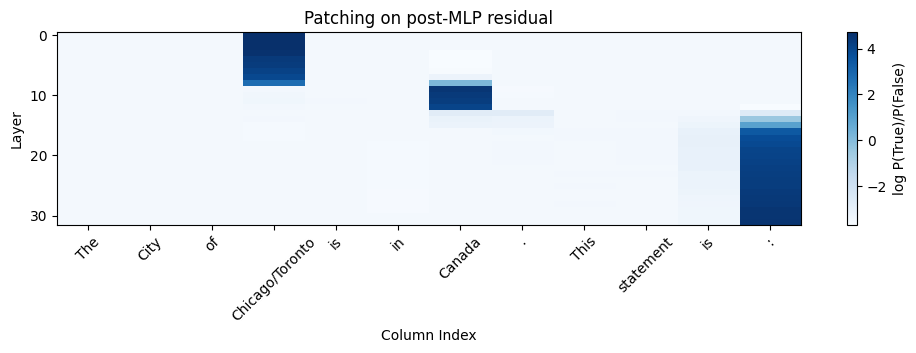

In [ ]:
cut = patching_result[:, -12:]
tokz = ['The', 'City', 'of', 'Chicago/Toronto', 'is', 'in', 'Canada', '.', 'This', 'statement', 'is', ':']

plt.figure(figsize=(12,2.5))
plt.imshow(cut.cpu(), cmap='Blues', interpolation='nearest', aspect='auto')
plt.colorbar(label='log P(True)/P(False)')
plt.title('Patching on post-MLP residual')
plt.xticks(ticks=range(len(tokz)), labels=tokz, rotation=45)
plt.xlabel('Column Index')
plt.ylabel('Layer')
plt.show()

## Get Activations

Here we get our dataset. We downsample counterfact_true_false down to 1000 to make it comparable to other domains. We also add 'This sentence is:' to the end of each statement for later intervention. We will keep track of the last token.

In [ ]:
databuilder = TrueFalseEasyBuilder()
dfs, df_all = databuilder.get_dataset()

# Preprocessing

df_all = df_all[df_all['filename'] != 'likely.csv']

# Trim the counterfact_true_false dataset to have balanced classes and a max of 1000 samples per class

target_df = df_all[df_all['filename'] == 'counterfact_true_false.csv']
label_0 = target_df[target_df['label'] == 0]
label_1 = target_df[target_df['label'] == 1]
retain_per_label = 1000
sampled_0 = label_0.sample(n=retain_per_label, random_state=42)
sampled_1 = label_1.sample(n=retain_per_label, random_state=42)
sampled_target_df = pd.concat([sampled_0, sampled_1])
df_all = pd.concat([df_all[df_all['filename'] != 'counterfact_true_false.csv'], sampled_target_df])
df_all['statement'] = df_all['statement'] + ' This sentence is:'

df_train, df_test = train_test_split(
    df_all,
    test_size=0.5,
    stratify=df_all['filename']
)

df_trimmed = df_train.iloc[:-(len(df_train) % probe_config.batch_size_extractor), :]
x = list(df_trimmed['statement'])
y = list(df_trimmed['label'])

Processing files: 100%|██████████| 16/16 [00:04<00:00,  3.97it/s]

WATCH OUT! Datapoints have different column entries depending on the csv



# Extract & Probe

Extract runs a transformerlens pipeline under the hood to get the activations for all layers, both for resid_post and for attn_z

In [ ]:
"""
heads will be a list (layers) of lists (heads) of tensors (head) with shape n_batches d_batch d_head
attn_labels is a tensor of with shape n_batches d_batch
resid_activations will be a dict (activations) of tensors (activation) with shape n_batches d_batch d_model
resid_labels is a tensor of with shape n_batches d_batch
"""

# Heads
attn_activations, attn_labels = extract(model, x, y, device=device, batch_size=probe_config.batch_size_extractor, attn=True)
heads = [decompose_mha(x) for x in attn_activations.values()]

# Residual stream
resid_activations, resid_labels = extract(model, x, y, device=device, batch_size=probe_config.batch_size_extractor, attn=False)

model.to(t.device('cpu'))
gc.collect()
t.cuda.empty_cache()

Moving model to device:  cuda
Moving model to device:  cuda


Processing: 100%|██████████| 286/286 [01:19<00:00,  3.61it/s]


Moving model to device:  cpu
Moving model to device:  cuda
Moving model to device:  cuda


Processing: 100%|██████████| 286/286 [01:27<00:00,  3.27it/s]


Moving model to device:  cpu
Moving model to device:  cpu


## Playing with KDE

Here we can visualize how activations look on a head that showed good separability. We compare that with PC projections to stress that the head is not specifically trained to separate true and false data

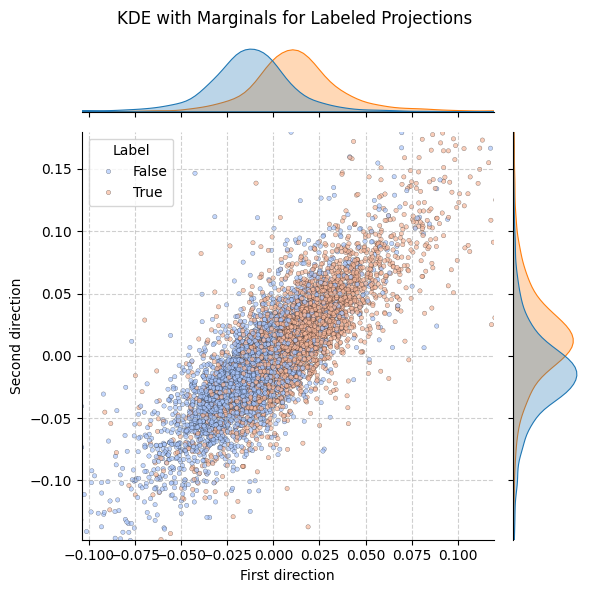

In [ ]:
from sklearn.linear_model import LogisticRegression

data = heads[15][2]                             # One of the good heads from llama
labels = 1 - attn_labels

probe = LogisticRegression(max_iter=probe_config.max_iter,
                                            solver="lbfgs",
                                            C=probe_config.C,
                                            random_state=probe_config.seed,
                                            n_jobs=-1)

kde(data=data, labels=labels, model=probe,
    n_dir=2, zoom_strength=0.5, adjust=0.01,    # Adjust according for the required viz
    kernel=False, scatter=True, pca=False)

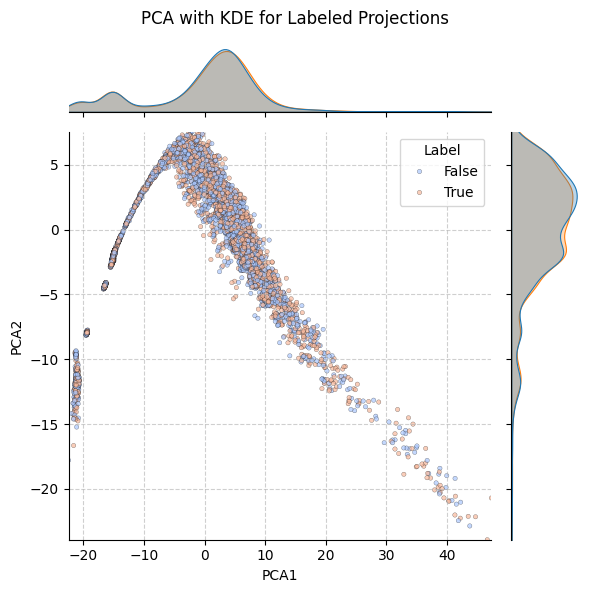

In [ ]:
# Plot PCA'd data for the same head

kde(data=data, labels=labels, model=probe,
    n_dir=2, zoom_strength=0.0, adjust=1,
    kernel=False, scatter=True, pca=True)

## Probe Sweeps (This part may take several minutes depending on resources)

We run a sweep of probes to the whole bag of activations and visualize their accuracies accordingly

### Heads

In [ ]:
probe_config.var_normalize = False
probe_config.verbose = False
tot_accuracies_heads = []
tot_directions_heads = []
tot_probes_heads = []

for layer in tqdm(range(len(heads)), desc="Layers"):
  accuracies, directions, probes = probe_sweep(heads[layer], attn_labels, probe_config)
  tot_accuracies_heads.append(accuracies)
  tot_directions_heads.append(directions)
  tot_probes_heads.append(probes)

tot_accuracies_heads = np.array(tot_accuracies_heads)

top_heads, top_values = get_top_heads(tot_accuracies_heads, 5)
print(top_heads, top_values)

Layers: 100%|██████████| 32/32 [21:02<00:00, 39.47s/it]

[[14 27]
 [16 28]
 [15 18]
 [16 31]
 [12 14]] [0.8569869  0.84497817 0.84497817 0.84388646 0.84279476]


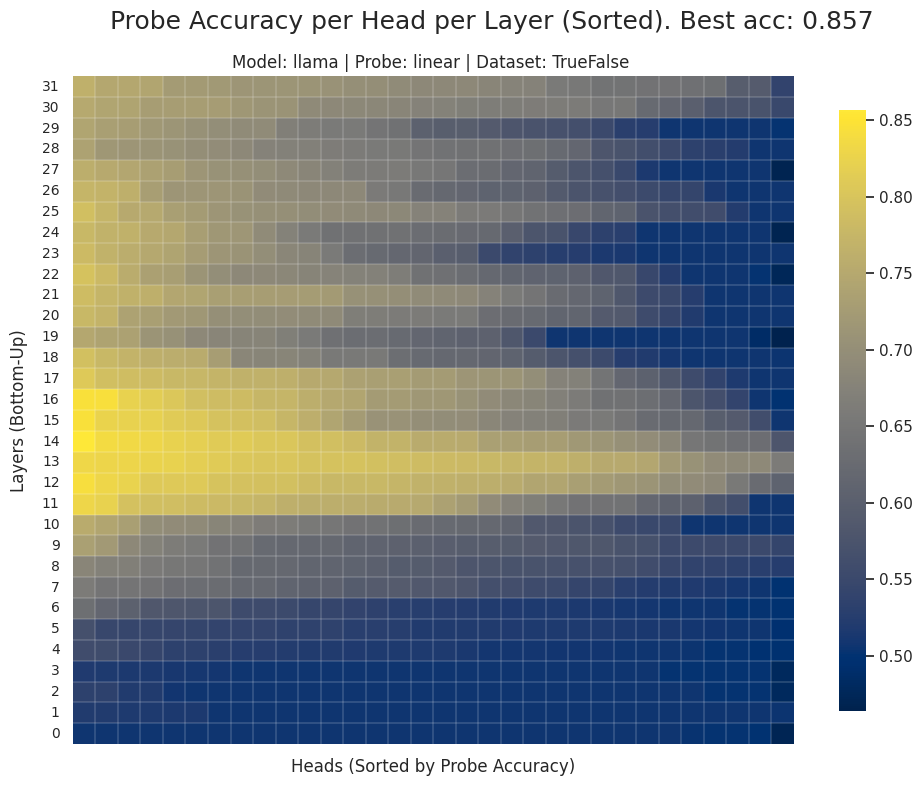

In [ ]:
pretty_heatmap(tot_accuracies_heads,
               title=f"Probe Accuracy per Head per Layer (Sorted). Best acc: {top_values[0]:.3f}",
               x_axis="Heads (Sorted by Probe Accuracy)",
               y_axis="Layers (Bottom-Up)",
               model=f'{MODEL}',
               probe=probe_config.probe_type,
               dataset="TrueFalse")

### Residual

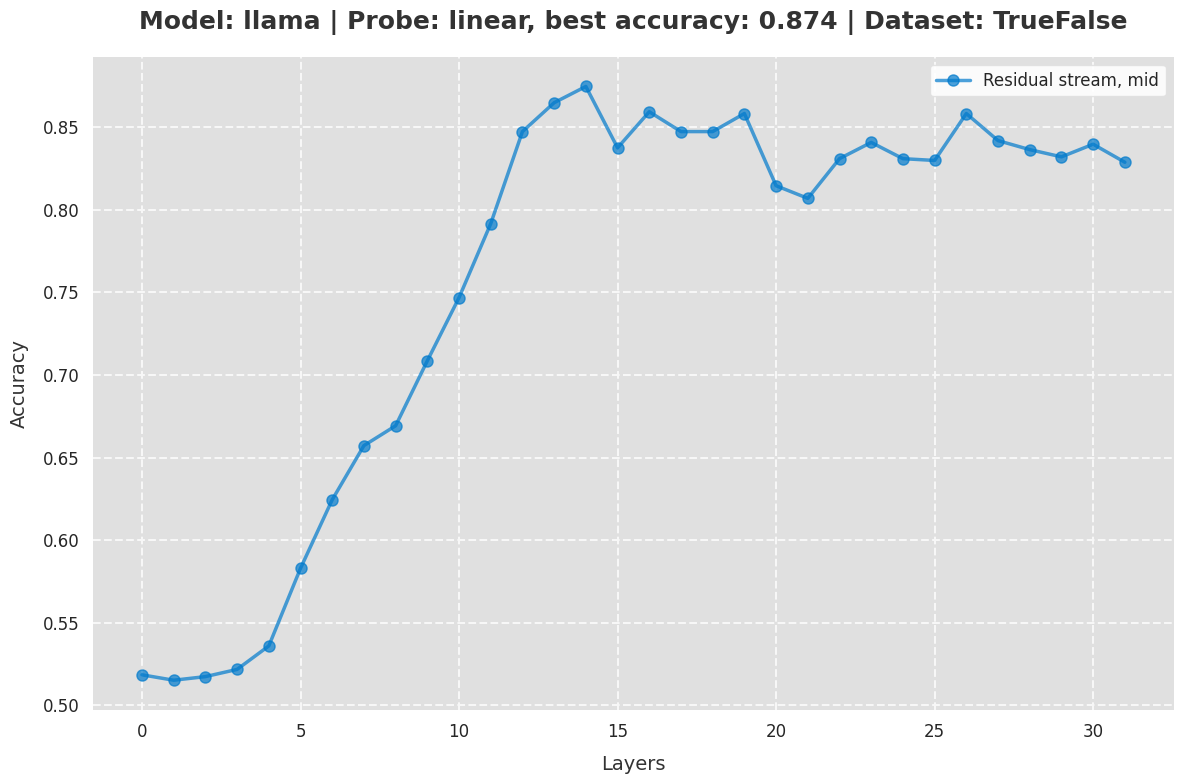

In [ ]:
# I didn't tqdm wrap the loop, the cell takes ~ the time of the sweep on attn heads

accuracies, directions, _ = probe_sweep(resid_activations.values(), resid_labels, probe_config)

pretty_line(x=accuracies,
            title=f"Model: {MODEL} | Probe: {probe_config.probe_type}, best accuracy: {np.array(accuracies).max():.3f} | Dataset: TrueFalse",
            x_axis="Layers",
            y_axis="Accuracy",
            x_label="Residual stream, mid",
            y_label="Accuracy")

# Intervene

From here we start on intervention. The results are slightly different than the one I reported because the mass-mean probes that I pickled were trained on a different random split, but the pattern of intervention effectiveness can be seen nonetheless.

We run the first cell if we need to intervene on heads and the second cell if we need to intervene on residual.

The parameters I set up on the last cell are designed for intervention on residual so I suggest to go that way

In [ ]:
probe_config.direction_type = 'mmp'
file_path = '/content/drive/My Drive/Finding_ES_LLM/'
model.to(t.device('cuda'))

# attn

with open(f'{file_path}thetas/{MODEL}_direction_{probe_config.direction_type}.pkl', 'rb') as file:
    directions = pickle.load(file)
with open(f'{file_path}thetas/{MODEL}_accuracies_{probe_config.direction_type}.pkl', 'rb') as file:
    accuracies = pickle.load(file)

directions = t.stack([t.stack(sublist, dim=0) for sublist in directions], dim=0).half()

Moving model to device:  cuda


In [ ]:
# resid

with open(f'{file_path}/thetas/{MODEL}_line_accuracies_{probe_config.direction_type}.pkl', 'rb') as file:
    accuracies = pickle.load(file)
with open(f'{file_path}/thetas/{MODEL}_line_directions_{probe_config.direction_type}.pkl', 'rb') as file:
    directions = pickle.load(file)

random_directions = [t.rand_like(x, dtype=t.float16) * 0.2 - 0.1 for x in directions]
directions = [x.half() for x in directions]


Here we separate the trues from the falses for the two directions of intervention.

We take a random sample of 100 for the K-alpha sweep

In [ ]:
df_for_int = df_test.copy()
df_for_int['statement'] = df_test['statement'].str[:-1]
df_true = df_for_int[df_for_int['label'] == 1]
df_false = df_for_int[df_for_int['label'] == 0]
df_to_test = df_true # Use df_true for True -> False and df_false for False -> True

test_sentences = list(df_to_test['statement'])
test_sample = random.sample(
                            test_sentences,
                            # len(test_sentences)              # Actual test, full dataset
                            100                                 # For sweeping purposes
                            )
sampled_df = df_to_test[df_to_test['statement'].isin(test_sample)]
prompts = list(sampled_df['statement'])
labels = list(sampled_df['label'])

Here we run the parameter sweep. When collecting the definitive result I just ran the sweep function on the whole dataset but with a single K and alpha

In [ ]:
''' == PARAMETER SWEEP == '''

best_k = 7
best_a = -4

# strength = np.abs(best_k*best_a/(model.cfg.n_heads*model.cfg.n_layers))
strength = np.abs(best_k*best_a/model.cfg.n_layers) # Resid
print("Intervention Strength: ", strength)

metric = 'boolprobs'

''' Find params through sweeping '''
ks = [3, 4, 5, 6, 7]
alphas = [0, -2, -4, -6, -8] if labels[0] == 1 else [0, 2, 3, 4, 5]     # We steer towards false if we have the true dataset and vice versa
''' Once you have found the best params, use them below with the full dataset'''
# ks = [best_k]
# alphas = [0, best_a]                                                  # We keep alpha=0 to see the original accuracy

with t.autocast(device_type="cuda", dtype=t.float16):

  for_sweep = parameter_sweep(
      model,
      prompts,
      accuracies,
      directions,
      ks=ks,
      alphas=alphas,
      metric=metric,
      secret=secrets['openai'],
      labels=labels,
      attn=False
  )

Intervention Strength:  0.875


0it [00:00, ?it/s]

Steering top 3 activations



0it [00:00, ?it/s]

0it [00:00, ?it/s]

With strength 0


...


3it [00:10,  3.60s/it]

4it [01:23, 18.06s/it]

With strength -6



4it [00:14,  3.59s/it]

4it [01:26, 18.06s/it]

With strength -8



5it [00:17,  3.59s/it]
5it [01:30, 18.05s/it]


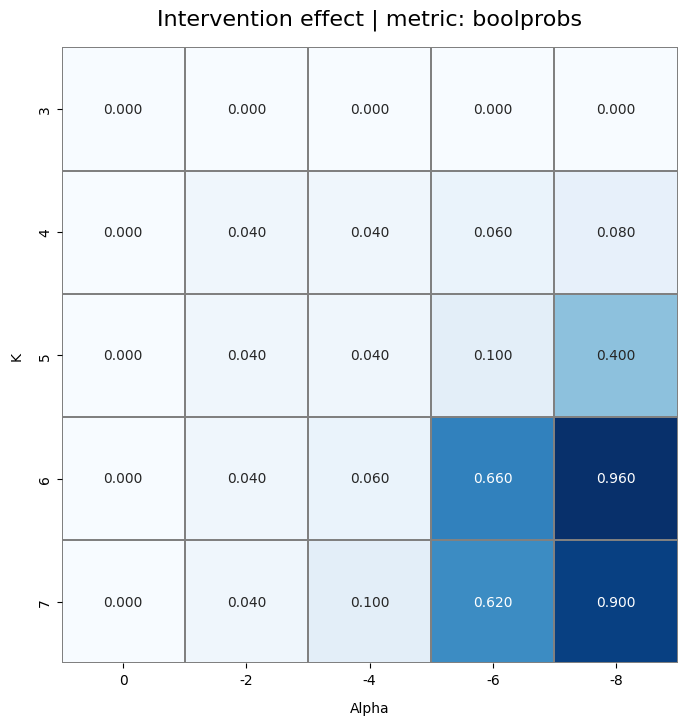

In [ ]:
boolp, probdiff = for_sweep

pretty_sweep(
             boolp,              # or boolp
             ks=ks,
             alphas=alphas,
             metric=metric
             )